# P9.2 Determine numerically (looking for the eigenvector) values of ergodic density for the random walk on selected network. [1P]


Node   | Numerical  | Analytical | Difference
----------------------------------------------
0      | 0.090909   | 0.090909   | 0.000000
1      | 0.062771   | 0.062771   | 0.000000
2      | 0.071429   | 0.071429   | 0.000000
3      | 0.038961   | 0.038961   | 0.000000
4      | 0.017316   | 0.017316   | 0.000000
5      | 0.030303   | 0.030303   | 0.000000
6      | 0.028139   | 0.028139   | 0.000000
7      | 0.028139   | 0.028139   | 0.000000
8      | 0.036797   | 0.036797   | 0.000000
9      | 0.006494   | 0.006494   | 0.000000
10     | 0.017316   | 0.017316   | 0.000000
11     | 0.006494   | 0.006494   | 0.000000
12     | 0.008658   | 0.008658   | 0.000000
13     | 0.036797   | 0.036797   | 0.000000
14     | 0.010823   | 0.010823   | 0.000000
15     | 0.015152   | 0.015152   | 0.000000
16     | 0.012987   | 0.012987   | 0.000000
17     | 0.006494   | 0.006494   | 0.000000
18     | 0.006494   | 0.006494   | 0.000000
19     | 0.010823   | 0.010823   | 0.000000
20     | 0.008658   | 0.008

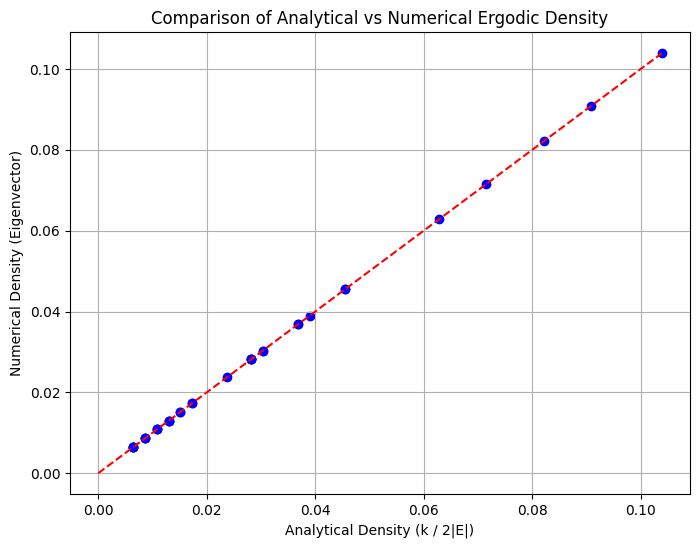

In [6]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
num_nodes = len(G.nodes)
num_edges = len(G.edges)

degrees = np.sum(A, axis=0)
P = np.zeros((num_nodes, num_nodes))

for i in range(num_nodes):
    for j in range(num_nodes):
        if degrees[i] > 0:
            P[j, i] = A[i, j] / degrees[i]


eigenvalues, eigenvectors = np.linalg.eig(P)

index_ev1 = np.argmin(np.abs(eigenvalues - 1))
stationary_vector = eigenvectors[:, index_ev1].real


ergodic_density_numerical = stationary_vector / np.sum(stationary_vector)
ergodic_density_analytical = degrees / np.sum(degrees)

print(f"{'Node':<6} | {'Numerical':<10} | {'Analytical':<10} | {'Difference':<10}")
print("-" * 46)
for i in range(num_nodes):
    diff = abs(ergodic_density_numerical[i] - ergodic_density_analytical[i])
    print(f"{i:<6} | {ergodic_density_numerical[i]:.6f}   | {ergodic_density_analytical[i]:.6f}   | {diff:.6f}")

plt.figure(figsize=(8, 6))
plt.scatter(ergodic_density_analytical, ergodic_density_numerical, color='blue')
plt.plot([0, max(ergodic_density_analytical)], [0, max(ergodic_density_analytical)], 'r--')
plt.xlabel('Analytical Density (k / 2|E|)')
plt.ylabel('Numerical Density (Eigenvector)')
plt.title('Comparison of Analytical vs Numerical Ergodic Density')
plt.grid(True)
plt.show()

# P9.3 Determine dynamically (by iterating the Markov operator) ergodic density for the random walk on selected network. [1P]

Converged in 146 iterations.
Node   | Dynamic    | Eigenvector | Diff      
----------------------------------------------
0      | 0.090909   | 0.090909   | 0.000000
1      | 0.062771   | 0.062771   | 0.000000
2      | 0.071429   | 0.071429   | 0.000000
3      | 0.038961   | 0.038961   | 0.000000
4      | 0.017316   | 0.017316   | 0.000000
5      | 0.030303   | 0.030303   | 0.000000
6      | 0.028139   | 0.028139   | 0.000000
7      | 0.028139   | 0.028139   | 0.000000
8      | 0.036797   | 0.036797   | 0.000000
9      | 0.006494   | 0.006494   | 0.000000


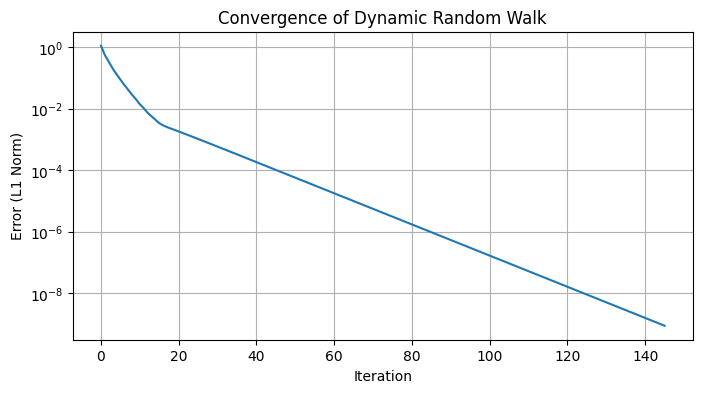

In [7]:
import numpy as np
import matplotlib.pyplot as plt

pi_dynamic = np.random.rand(num_nodes)
pi_dynamic = pi_dynamic / np.sum(pi_dynamic)


tolerance = 1e-9
max_iter = 1000
diff = 1.0
iterations = 0

history = []

while diff > tolerance and iterations < max_iter:
    pi_next = P.dot(pi_dynamic)
    
    diff = np.linalg.norm(pi_next - pi_dynamic, ord=1)
    pi_next = pi_next / pi_next.sum()
    pi_dynamic = pi_next
    history.append(diff)
    iterations += 1

print(f"Converged in {iterations} iterations.")

print(f"{'Node':<6} | {'Dynamic':<10} | {'Eigenvector':<10} | {'Diff':<10}")
print("-" * 46)
for i in range(min(10, num_nodes)):
    d_dyn = pi_dynamic[i]
    d_eig = ergodic_density_numerical[i]
    print(f"{i:<6} | {d_dyn:.6f}   | {d_eig:.6f}   | {abs(d_dyn - d_eig):.6f}")

plt.figure(figsize=(8, 4))
plt.plot(history)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Error (L1 Norm)')
plt.title('Convergence of Dynamic Random Walk')
plt.grid(True)
plt.show()

# P9.5 Determine the value of classic or modified pagerank for the selected network. [1.5P]

In [12]:
import networkx as nx
import numpy as np

G = nx.karate_club_graph()
N = len(G)

d = 0.85
pr_nx = nx.pagerank(G, alpha=d)

A = nx.to_numpy_array(G)

degrees = np.sum(A, axis=1)

P = np.zeros((N, N))
for i in range(N):
    if degrees[i] == 0:
        P[:, i] = 1.0 / N
    else:
        P[:, i] = A[i, :] / degrees[i]

J = np.ones((N, N)) / N
G_matrix = d * P + (1 - d) * J

pi = np.ones(N) / N

tolerance = 1e-12
max_iter = 10000

for _ in range(max_iter):
    pi_next = G_matrix.dot(pi)
    pi_next = pi_next / pi_next.sum()

    if np.linalg.norm(pi_next - pi, 1) < tolerance:
        pi = pi_next
        break

    pi = pi_next

print(f"{'Node':<6} | {'NetworkX':<10} | {'Manual':<10} | {'Diff':<10}")
print("-" * 46)
for i in range(10):
    val_nx = pr_nx[i]
    val_man = pi[i]
    print(f"{i:<6} | {val_nx:.6f}   | {val_man:.6f}   | {abs(val_nx - val_man):.6f}")


Node   | NetworkX   | Manual     | Diff      
----------------------------------------------
0      | 0.088508   | 0.088500   | 0.000008
1      | 0.057415   | 0.057412   | 0.000003
2      | 0.062767   | 0.062766   | 0.000001
3      | 0.037212   | 0.037210   | 0.000002
4      | 0.020504   | 0.020501   | 0.000003
5      | 0.033810   | 0.033804   | 0.000007
6      | 0.031529   | 0.031523   | 0.000006
7      | 0.026465   | 0.026463   | 0.000001
8      | 0.033382   | 0.033382   | 0.000001
9      | 0.009463   | 0.009463   | 0.000000


# P9.6 Find a graph with a fixed number of edges and vertices where diffusion occurs fastest (hint: value a second eigenvalue can help). [3.5P]

Searching for graph with N=20, M=30 with fastest diffusion
Graph Type      | 2nd Eigenvalue  | Speed     
---------------------------------------------
Lattice (Slow)  | 0.967371          | Slow
Random (Fast)   | 0.901875          | Fast
Optimized       | 0.797083          | Fastest


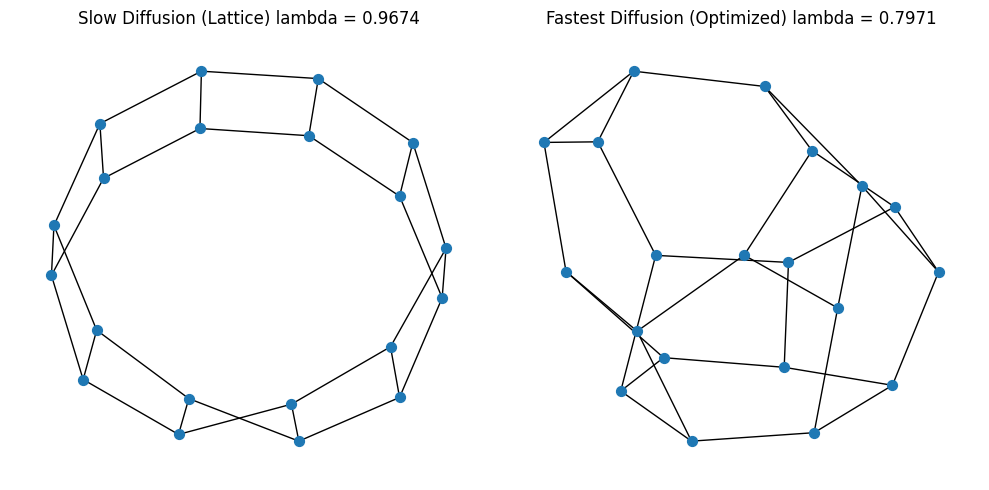

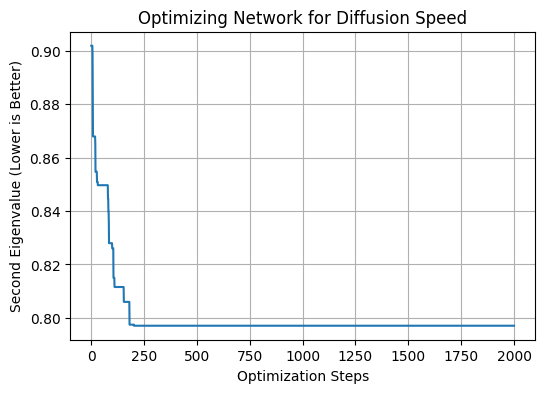

In [13]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

def get_second_eigenvalue(G):
    """Calculates the second largest eigenvalue modulus (SLEM) of the random-walk transition matrix."""
    if not nx.is_connected(G):
        return 1.0

    A = nx.to_numpy_array(G)
    degrees = np.sum(A, axis=1)  # row-sum (outgoing)

    P = np.zeros_like(A, dtype=float)
    for i in range(len(G)):
        if degrees[i] > 0:
            # column-stochastic: column i sums to 1
            P[:, i] = A[i, :] / degrees[i]
        else:
            # (shouldn't happen in a connected undirected graph, but safe)
            P[:, i] = 1.0 / len(G)

    evals = np.linalg.eigvals(P)
    evals_abs = np.abs(evals)

    # Find the eigenvalue closest to 1 (the trivial one), then take the largest modulus among the rest
    idx1 = np.argmin(np.abs(evals - 1.0))
    evals_abs_wo1 = np.delete(evals_abs, idx1)

    return np.max(evals_abs_wo1)

N = 20
k = 3
M = int(N * k / 2)

print(f"Searching for graph with N={N}, M={M} with fastest diffusion")

# --- Slow diffusion baseline with exactly N vertices and M edges ---
# watts_strogatz_graph requires even k; for (N=20,k=3) use a circulant graph:
# connect to +/-1 plus the opposite node (N/2 step), giving degree 3 and M = N + N/2.
if k == 3 and N % 2 == 0:
    G_slow = nx.circulant_graph(N, [1, N // 2])
else:
    # fallback: if k is even, use ring lattice WS(p=0)
    if k % 2 != 0:
        raise ValueError("For watts_strogatz_graph, k must be even. Choose even k or use a custom lattice.")
    G_slow = nx.watts_strogatz_graph(N, k, p=0.0)

lambda_slow = get_second_eigenvalue(G_slow)

# --- Fast-ish starting point with fixed edges ---
# For fixed degree k, a random k-regular graph often mixes fast and has exactly M edges.
# If this fails (e.g., impossible k,N combo), fall back to gnm_random_graph(N, M).
try:
    G_fast = nx.random_regular_graph(k, N)
    while not nx.is_connected(G_fast):
        G_fast = nx.random_regular_graph(k, N)
except nx.NetworkXError:
    G_fast = nx.gnm_random_graph(N, M)
    while not nx.is_connected(G_fast):
        G_fast = nx.gnm_random_graph(N, M)

lambda_fast = get_second_eigenvalue(G_fast)

G_opt = G_fast.copy()
lambda_opt = lambda_fast
iterations = 2000

history = [lambda_opt]

for _ in range(iterations):
    edges = list(G_opt.edges())
    if len(edges) < 2:
        break

    e1, e2 = random.sample(edges, 2)
    u, v = e1
    x, y = e2

    # avoid self-loops / repeated vertices
    if len({u, v, x, y}) != 4:
        history.append(lambda_opt)
        continue

    # try both rewiring patterns to explore more:
    # pattern A: (u,x) and (v,y)
    # pattern B: (u,y) and (v,x)
    if random.random() < 0.5:
        a1, a2, b1, b2 = u, x, v, y
    else:
        a1, a2, b1, b2 = u, y, v, x

    # avoid multi-edges
    if G_opt.has_edge(a1, a2) or G_opt.has_edge(b1, b2):
        history.append(lambda_opt)
        continue

    # do the swap
    G_opt.remove_edge(u, v)
    G_opt.remove_edge(x, y)
    G_opt.add_edge(a1, a2)
    G_opt.add_edge(b1, b2)

    # accept only if connected and improves SLEM
    if nx.is_connected(G_opt):
        new_lambda = get_second_eigenvalue(G_opt)
        if new_lambda < lambda_opt:
            lambda_opt = new_lambda
        else:
            # revert
            G_opt.remove_edge(a1, a2)
            G_opt.remove_edge(b1, b2)
            G_opt.add_edge(u, v)
            G_opt.add_edge(x, y)
    else:
        # revert
        G_opt.remove_edge(a1, a2)
        G_opt.remove_edge(b1, b2)
        G_opt.add_edge(u, v)
        G_opt.add_edge(x, y)

    history.append(lambda_opt)

print(f"{'Graph Type':<15} | {'2nd Eigenvalue':<15} | {'Speed':<10}")
print("-" * 45)
print(f"{'Lattice (Slow)':<15} | {lambda_slow:.6f}          | Slow")
print(f"{'Random (Fast)':<15} | {lambda_fast:.6f}          | Fast")
print(f"{'Optimized':<15} | {lambda_opt:.6f}          | Fastest")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
nx.draw(G_slow, node_size=50)
plt.title(f"Slow Diffusion (Lattice) lambda = {lambda_slow:.4f}")

plt.subplot(1, 2, 2)
nx.draw(G_opt, node_size=50)
plt.title(f"Fastest Diffusion (Optimized) lambda = {lambda_opt:.4f}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel('Optimization Steps')
plt.ylabel('Second Eigenvalue (Lower is Better)')
plt.title('Optimizing Network for Diffusion Speed')
plt.grid(True)
plt.show()



Processing Scenario 1: Small Ring (N=20)
  -> Started: 1.0000
  -> Finished: 1.0000

Processing Scenario 2: Medium Scale-Free (N=50)
  -> Started: 0.7801
  -> Finished: 0.7313

Processing Scenario 3: Large Random (N=100)
  -> Started: 0.6215
  -> Finished: 0.5470


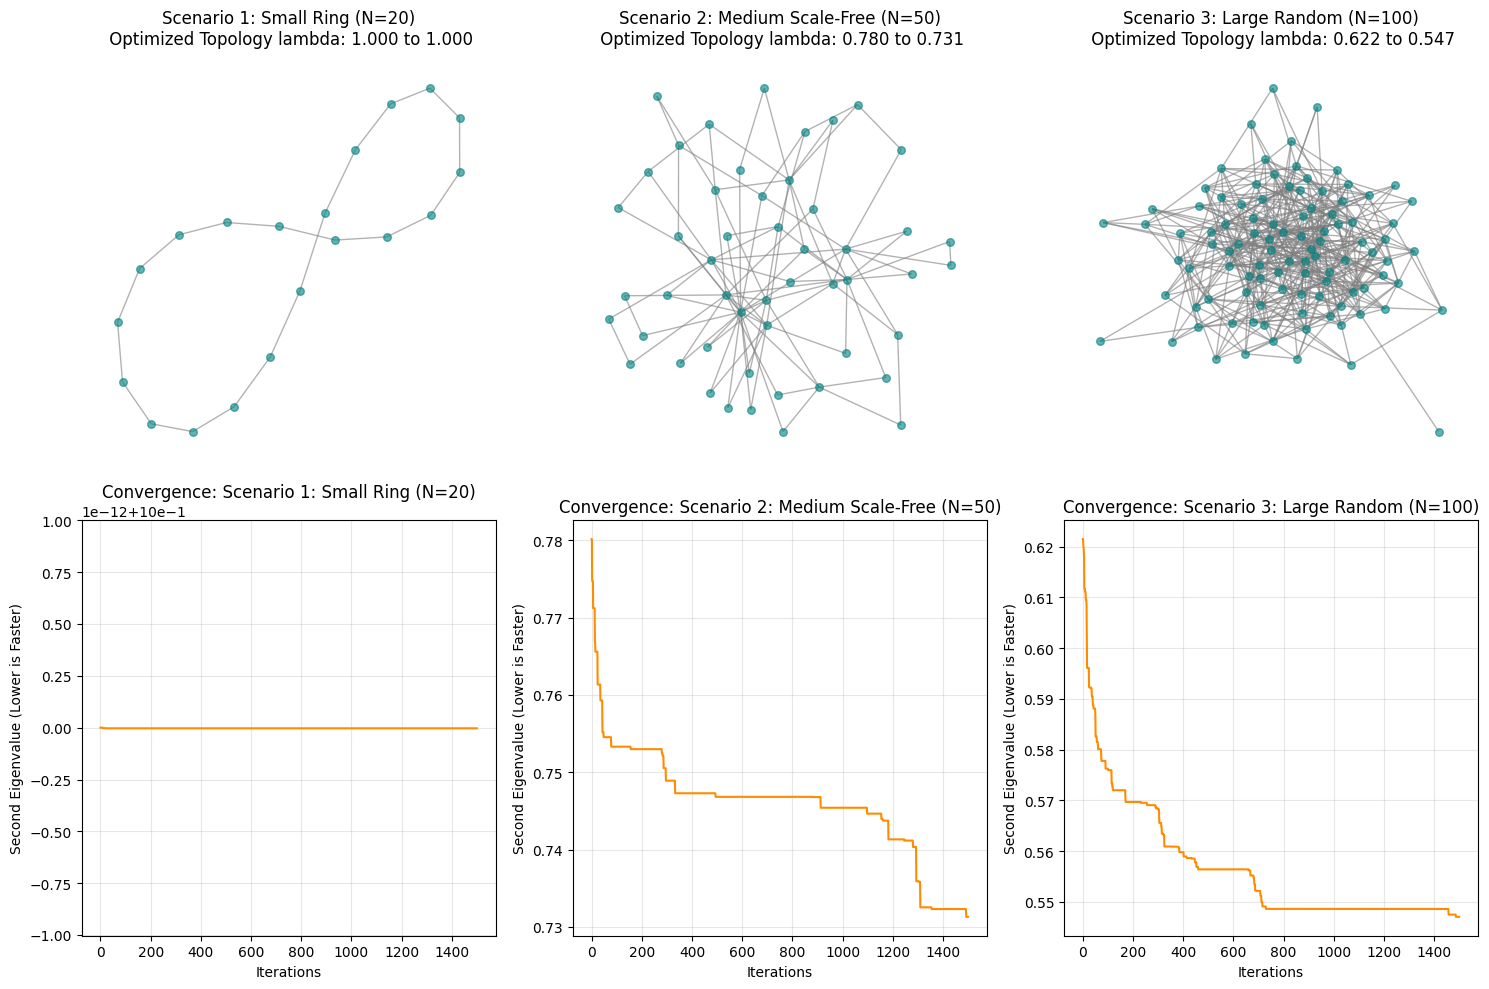

In [14]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

def get_second_eigenvalue(G):
    """Calculates the second largest eigenvalue modulus (SLEM)."""
    if not nx.is_connected(G):
        return 1.0

    A = nx.to_numpy_array(G)
    degrees = np.sum(A, axis=1)  # row degree (outgoing)
    N = len(G)

    P = np.zeros_like(A, dtype=float)
    for i in range(N):
        if degrees[i] > 0:
            # column-stochastic operator: column i sums to 1
            P[:, i] = A[i, :] / degrees[i]
        else:
            # dangling node (shouldn't happen if connected + undirected, but safe)
            P[:, i] = 1.0 / N

    evals = np.linalg.eigvals(P)

    # remove the eigenvalue closest to 1, then take max modulus of the rest
    idx1 = np.argmin(np.abs(evals - 1.0))
    evals_abs = np.abs(evals)
    evals_abs_wo1 = np.delete(evals_abs, idx1)

    return np.max(evals_abs_wo1) if len(evals_abs_wo1) > 0 else 0.0


def optimize_graph(G_start, iterations=1000):
    """Hill-climbing optimization to minimize lambda_2."""
    G_curr = G_start.copy()
    current_lambda = get_second_eigenvalue(G_curr)
    history = [current_lambda]

    for _ in range(iterations):
        edges = list(G_curr.edges())
        if len(edges) < 2:
            break

        e1, e2 = random.sample(edges, 2)
        u, v = e1
        x, y = e2

        if len({u, v, x, y}) != 4:
            history.append(current_lambda)
            continue

        # try one of the two possible rewirings at random to explore more
        if random.random() < 0.5:
            a1, a2, b1, b2 = u, x, v, y
        else:
            a1, a2, b1, b2 = u, y, v, x

        if G_curr.has_edge(a1, a2) or G_curr.has_edge(b1, b2):
            history.append(current_lambda)
            continue

        G_curr.remove_edge(u, v)
        G_curr.remove_edge(x, y)
        G_curr.add_edge(a1, a2)
        G_curr.add_edge(b1, b2)

        if nx.is_connected(G_curr):
            new_lambda = get_second_eigenvalue(G_curr)
            if new_lambda < current_lambda:
                current_lambda = new_lambda
            else:
                G_curr.remove_edge(a1, a2)
                G_curr.remove_edge(b1, b2)
                G_curr.add_edge(u, v)
                G_curr.add_edge(x, y)
        else:
            G_curr.remove_edge(a1, a2)
            G_curr.remove_edge(b1, b2)
            G_curr.add_edge(u, v)
            G_curr.add_edge(x, y)

        history.append(current_lambda)

    return G_curr, history


scenarios = [
    {
        "name": "Scenario 1: Small Ring (N=20)",
        "N": 20,
        "type": "ring",
        "k": 2
    },
    {
        "name": "Scenario 2: Medium Scale-Free (N=50)",
        "N": 50,
        "type": "barabasi",
        "m": 2
    },
    {
        "name": "Scenario 3: Large Random (N=100)",
        "N": 100,
        "type": "random",
        "p": 0.08
    }
]

results = []

plt.figure(figsize=(15, 10))

for idx, sc in enumerate(scenarios):
    N = sc["N"]
    print(f"\nProcessing {sc['name']}")
    
    if sc["type"] == "ring":
        G_initial = nx.watts_strogatz_graph(N, k=sc["k"], p=0.0)
    elif sc["type"] == "barabasi":
        G_initial = nx.barabasi_albert_graph(N, m=sc["m"])
    elif sc["type"] == "random":
        G_initial = nx.erdos_renyi_graph(N, p=sc["p"])
        while not nx.is_connected(G_initial):
            G_initial = nx.erdos_renyi_graph(N, p=sc["p"])
            
    lambda_start = get_second_eigenvalue(G_initial)
    
    G_opt, history = optimize_graph(G_initial, iterations=1500)
    lambda_end = history[-1]
    
    print(f"  -> Started: {lambda_start:.4f}")
    print(f"  -> Finished: {lambda_end:.4f}")
    

    plt.subplot(2, 3, idx + 1)
    pos = nx.spring_layout(G_opt, seed=42)
    nx.draw(G_opt, pos, node_size=30, node_color='teal', edge_color='gray', alpha=0.6)
    plt.title(f"{sc['name']}\n Optimized Topology lambda: {lambda_start:.3f} to {lambda_end:.3f}")

    plt.subplot(2, 3, idx + 4)
    plt.plot(history, color='darkorange')
    plt.xlabel("Iterations")
    plt.ylabel("Second Eigenvalue (Lower is Faster)")
    plt.grid(True, alpha=0.3)
    plt.title(f"Convergence: {sc['name']}")

plt.tight_layout()
plt.show()